 1. Setup Awal

In [3]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. Melatih dan Memvisualisasikan Decision Tree (Klasifikasi)

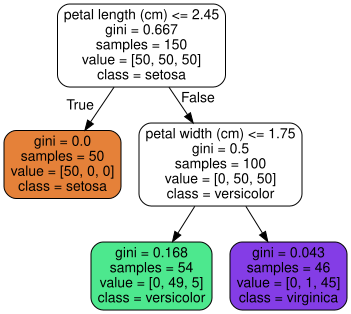

In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from graphviz import Source
from sklearn import datasets # Import the datasets module

# Memuat dataset Iris
iris = datasets.load_iris()
X = iris.data[:, 2:] # Hanya menggunakan fitur petal length dan petal width
y = iris.target

# Melatih model Decision Tree Classifier
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# Membuat file visualisasi .dot dari tree yang sudah dilatih
export_graphviz(
        tree_clf,
        out_file=os.path.join(".", "iris_tree.dot"),
        feature_names=iris.feature_names[2:],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

# Menampilkan gambar tree dari file .dot
# CATATAN: Mungkin perlu menginstal library graphviz: pip install graphviz
Source.from_file(os.path.join(".", "iris_tree.dot"))

3. Membuat Prediksi dan Estimasi Probabilitas

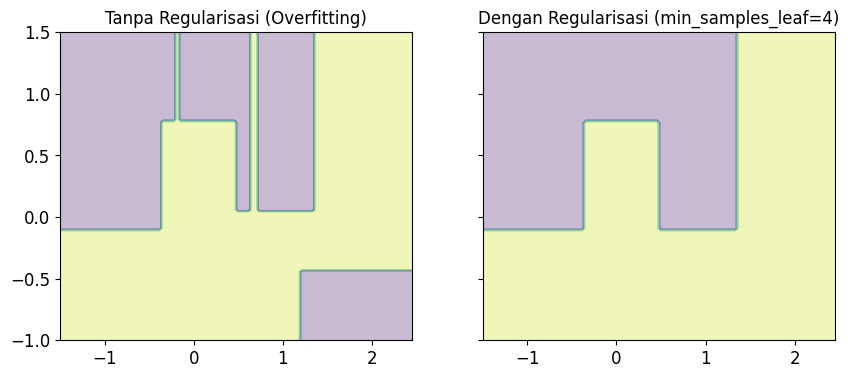

In [5]:
from sklearn.datasets import make_moons

# Membuat dataset moons yang tidak bisa dipisahkan secara linear
X, y = make_moons(n_samples=100, noise=0.25, random_state=53)

# Melatih dua model: satu tanpa regularisasi, satu dengan regularisasi
tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
tree_clf1.fit(X, y)
tree_clf2.fit(X, y)

# Fungsi untuk plot decision boundary (dari chapter sebelumnya)
def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap='viridis')

# Plot hasil kedua model
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X, y, axes=[-1.5, 2.45, -1, 1.5])
plt.title("Tanpa Regularisasi (Overfitting)")

plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X, y, axes=[-1.5, 2.45, -1, 1.5])
plt.title("Dengan Regularisasi (min_samples_leaf=4)")

plt.show()

4. Regularisasi Decision Tree

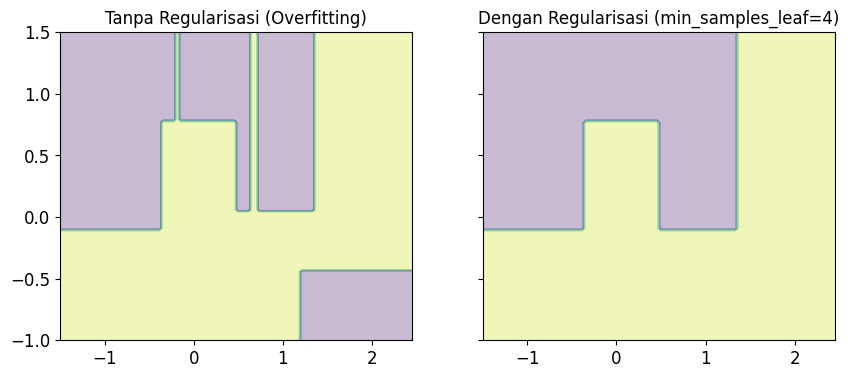

In [6]:
from sklearn.datasets import make_moons

# Membuat dataset moons yang tidak bisa dipisahkan secara linear
X, y = make_moons(n_samples=100, noise=0.25, random_state=53)

# Melatih dua model: satu tanpa regularisasi, satu dengan regularisasi
tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=4, random_state=42)
tree_clf1.fit(X, y)
tree_clf2.fit(X, y)

# Fungsi untuk plot decision boundary (dari chapter sebelumnya)
def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap='viridis')

# Plot hasil kedua model
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X, y, axes=[-1.5, 2.45, -1, 1.5])
plt.title("Tanpa Regularisasi (Overfitting)")

plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X, y, axes=[-1.5, 2.45, -1, 1.5])
plt.title("Dengan Regularisasi (min_samples_leaf=4)")

plt.show()

5. Decision Tree untuk Regresi

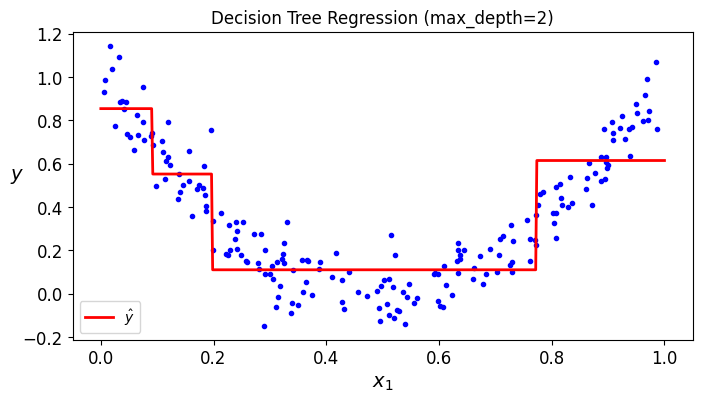

In [7]:
from sklearn.tree import DecisionTreeRegressor

# Membuat data kuadratik acak
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5)**2 + np.random.randn(m, 1) / 10

# Melatih model Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X, y)

# Visualisasi hasil regresi
X_new = np.linspace(0, 1, 500).reshape(-1, 1)
y_predict = tree_reg.predict(X_new)

plt.figure(figsize=(8,4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_predict, "r-", linewidth=2, label=r"$\hat{y}$")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.title("Decision Tree Regression (max_depth=2)")
plt.legend()
plt.show()

6. Ketidakstabilan Decision Tree

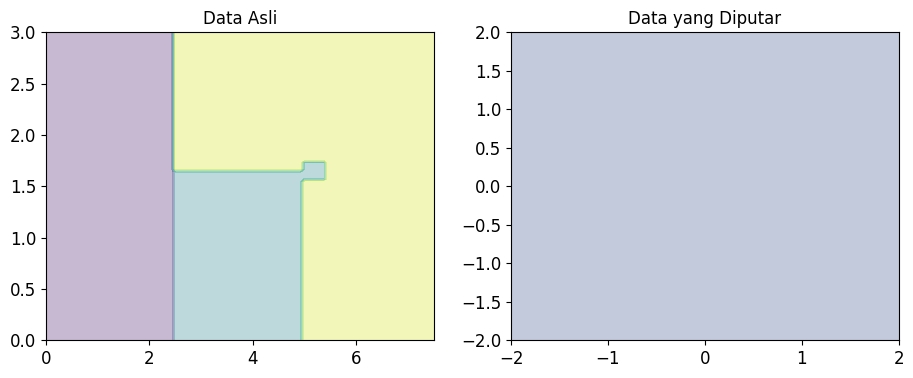

In [8]:
# Memuat kembali dataset Iris
X = iris.data[:, 2:]
y = iris.target

# Memutar data sebesar 45 derajat
angle = np.pi / 180 * 45
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
X_rotated = X.dot(rotation_matrix)

# Melatih dua model pada data asli dan data yang sudah diputar
tree_clf_reg = DecisionTreeClassifier(random_state=42)
tree_clf_reg.fit(X, y)

tree_clf_rot = DecisionTreeClassifier(random_state=42)
tree_clf_rot.fit(X_rotated, y)

# Plot kedua decision boundary
plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_decision_boundary(tree_clf_reg, X, y, axes=[0, 7.5, 0, 3])
plt.title("Data Asli")
plt.subplot(122)
plot_decision_boundary(tree_clf_rot, X_rotated, y, axes=[-2, 2, -2, 2])
plt.title("Data yang Diputar")
plt.show()

Penjelasan Kode
Bagian 1. Setup Awal: Seperti biasa, bagian ini mempersiapkan semua library yang dibutuhkan.

Bagian 2. Melatih dan Memvisualisasikan Decision Tree: Bagian ini adalah inti dari chapter.

Kita menggunakan dataset Iris dan hanya fokus pada dua fitur (petal length dan petal width) agar mudah divisualisasikan.

DecisionTreeClassifier adalah model yang kita latih. max_depth=2 adalah sebuah hyperparameter yang membatasi kedalaman pohon hanya sampai 2 level, agar tidak terlalu rumit dan mudah dipahami.

export_graphviz adalah fungsi yang sangat berguna untuk mengekspor struktur pohon yang sudah dilatih ke dalam format file .dot.

Source.from_file kemudian membaca file .dot tersebut dan menampilkannya sebagai gambar. Dalam gambar pohon, Anda bisa melihat:

Aturan: Setiap node (kotak) berisi aturan, contoh: "petal width (cm) <= 0.8".

Gini: Ukuran "ketidakmurnian" (impurity). Nilai 0 berarti semua data di node tersebut berasal dari kelas yang sama (murni).

Samples: Jumlah data latih yang masuk ke node tersebut.

Value: Distribusi jumlah data untuk setiap kelas.

Class: Kelas mayoritas di node tersebut.

Bagian 3. Membuat Prediksi dan Estimasi Probabilitas:

.predict(): Untuk membuat prediksi, kita cukup menelusuri pohon dari atas (root) mengikuti aturan "if-else" hingga sampai ke daun (leaf node). Kelas mayoritas di daun itulah yang menjadi hasil prediksi.

.predict_proba(): Ini memberikan probabilitas untuk setiap kelas, yang dihitung dari rasio instance kelas di daun tempat data baru tersebut jatuh.

Bagian 4. Regularisasi Decision Tree: Ini adalah konsep yang sangat penting.

Overfitting: Jika tidak dibatasi, Decision Tree akan terus membelah data hingga setiap daun menjadi murni. Ini akan membuat model sangat "hafal" dengan data latih tetapi performanya buruk pada data baru. Ini disebut overfitting, seperti yang ditunjukkan pada grafik kiri.

Regularisasi: Untuk mencegah overfitting, kita bisa membatasi "kebebasan" model. min_samples_leaf=4 adalah salah satu cara regularisasi, yang artinya sebuah daun hanya bisa dibuat jika ia berisi setidaknya 4 data. Ini memaksa model untuk lebih general dan tidak terlalu detail, seperti yang terlihat pada grafik kanan.

Bagian 5. Decision Tree untuk Regresi: Decision Tree tidak hanya untuk klasifikasi, tapi juga bisa untuk tugas regresi (memprediksi nilai kontinu).

DecisionTreeRegressor bekerja dengan cara yang sama, yaitu membagi data berdasarkan fitur.

Namun, alih-alih memprediksi kelas di setiap daun, ia memprediksi satu nilai numerik yang merupakan rata-rata dari semua nilai target data latih yang ada di daun tersebut. Inilah sebabnya mengapa garis prediksinya berbentuk undakan atau tangga (step-like).

Bagian 6. Ketidakstabilan Decision Tree: Bagian ini menunjukkan salah satu kelemahan utama dari Decision Tree. Model ini sangat sensitif terhadap perubahan kecil pada data latih, termasuk rotasi. Seperti yang terlihat di grafik, hanya dengan memutar data, batas keputusan yang dihasilkan menjadi sangat berbeda. Kelemahan inilah yang menjadi alasan utama mengapa model ensemble seperti Random Forest (yang merupakan gabungan dari banyak Decision Tree) seringkali lebih disukai dalam praktik.